# 📱 Customer Churn Analysis & Prediction
## Telecom Industry — Retention Analytics

### Problem Statement
A telecom company with 7,043 customers faces 26.54% monthly 
churn — nearly 2x the industry benchmark of 15%.
$1.67M annual revenue is at risk.

**Goal:** Identify at-risk customers and predict churn 
before it happens using machine learning.

**Tools:** Python · SQL · Tableau
**Dataset:** IBM Telco Customer Churn (Kaggle)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
df = pd.read_csv( r'C:\Users\ramha\Desktop\telco_churn_cleaned.csv\telco_churn_cleaned.csv'
)

print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded successfully
Shape: 7,043 rows × 35 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = pd.read_csv(r'C:\Users\ramha\Desktop\telco_churn_cleaned.csv\telco_churn_cleaned.csv', 
                 usecols=range(25))

print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head()

✅ Dataset loaded successfully
Shape: 7,043 rows × 25 columns

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Tenure_Band', 'Charge_Segment', 'Contract_Risk', 'Churn_Value']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Tenure_Band,Charge_Segment,Contract_Risk,Churn_Value
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-3 Months,Low,High Risk,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,Medium,Medium Risk,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-3 Months,Medium,High Risk,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months,Medium,Medium Risk,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-3 Months,High,High Risk,1


In [4]:
print("=" * 50)
print("     CHURN ANALYSIS — DATA QUALITY REPORT")
print("=" * 50)

print(f"\n📌 Total Customers      : {len(df):,}")
print(f"📌 Total Features       : {df.shape[1]}")
print(f"📌 Missing Values       : {df.isnull().sum().sum()}")
print(f"📌 Duplicate Rows       : {df.duplicated().sum()}")

print(f"\n📌 Churned Customers    : {(df['Churn']=='Yes').sum():,}")
print(f"📌 Retained Customers   : {(df['Churn']=='No').sum():,}")
print(f"📌 Churn Rate           : {(df['Churn']=='Yes').sum()/len(df)*100:.2f}%")

print(f"\n📌 Avg Monthly Charges  : ${df['MonthlyCharges'].mean():.2f}")
print(f"📌 Avg Tenure           : {df['tenure'].mean():.1f} months")
print(f"📌 Avg Total Charges    : ${df['TotalCharges'].mean():.2f}")

print("\n📌 Contract Distribution:")
print(df['Contract'].value_counts())

print("\n📌 Internet Service:")
print(df['InternetService'].value_counts())
print("=" * 50)

     CHURN ANALYSIS — DATA QUALITY REPORT

📌 Total Customers      : 7,043
📌 Total Features       : 25
📌 Missing Values       : 0
📌 Duplicate Rows       : 0

📌 Churned Customers    : 1,869
📌 Retained Customers   : 5,174
📌 Churn Rate           : 26.54%

📌 Avg Monthly Charges  : $64.76
📌 Avg Tenure           : 32.4 months
📌 Avg Total Charges    : $2279.73

📌 Contract Distribution:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

📌 Internet Service:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


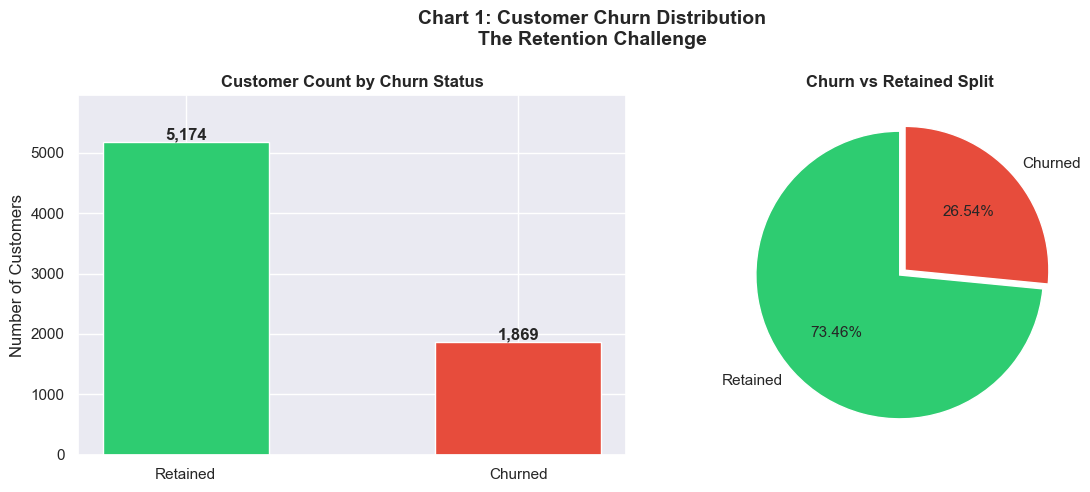

✅ Chart 1 saved

💡 Story: 26.54% churn rate
   Industry benchmark is 15% — we are 11.54% above benchmark
   Every 4th customer is leaving — critical retention problem


In [7]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 1: Customer Churn Distribution\nThe Retention Challenge',
             fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
labels = ['Retained', 'Churned']
counts = [(df['Churn']=='No').sum(), (df['Churn']=='Yes').sum()]

# Bar Chart
axes[0].bar(labels, counts, color=colors, width=0.5)
axes[0].set_title('Customer Count by Churn Status', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(counts) * 1.15)
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, f'{v:,}', ha='center',
                 fontweight='bold', fontsize=12)

# Pie Chart
axes[1].pie(counts, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90,
            explode=(0, 0.05), textprops={'fontsize': 11})
axes[1].set_title('Churn vs Retained Split', fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\chart1_churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 1 saved")
print(f"\n💡 Story: {(df['Churn']=='Yes').sum()/len(df)*100:.2f}% churn rate")
print(f"   Industry benchmark is 15% — we are {26.54-15:.2f}% above benchmark")
print(f"   Every 4th customer is leaving — critical retention problem")

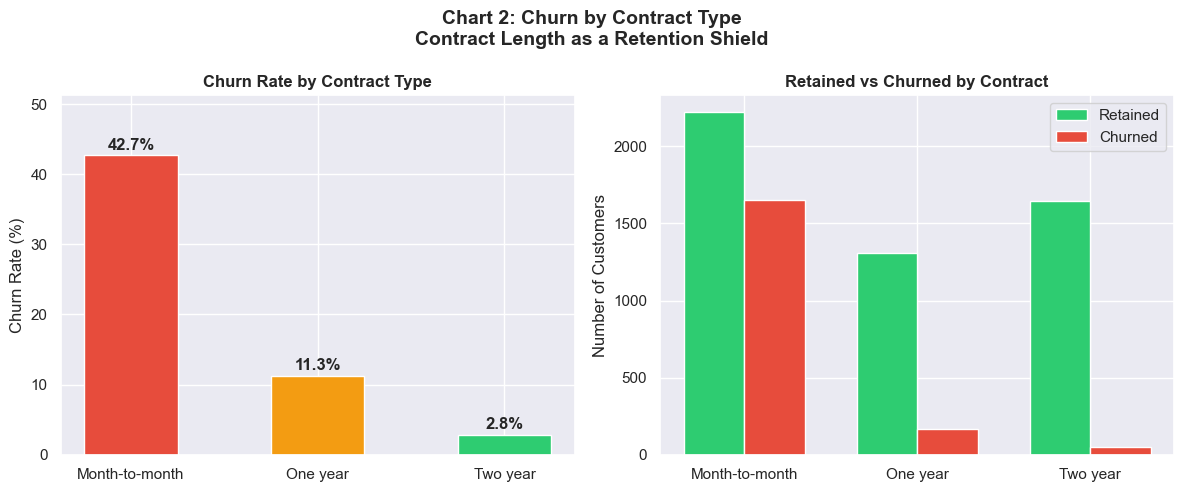

✅ Chart 2 saved

💡 Story: Month-to-month customers churn at 11.3% vs 42.7% (1yr) and 2.8% (2yr)
   Long-term contracts act as a retention shield
   Recommendation: Incentivize customers to upgrade to annual contracts


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 2: Churn by Contract Type\nContract Length as a Retention Shield',
             fontsize=14, fontweight='bold')

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_counts = df.groupby('Contract')['Churn'].value_counts().unstack()
contracts = contract_churn.index.tolist()
churn_rates = contract_churn['Yes'].values * 100
colors_bar = ['#e74c3c', '#f39c12', '#2ecc71']

# Bar Chart — Churn Rate %
axes[0].bar(contracts, churn_rates, color=colors_bar, width=0.5)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, max(churn_rates) * 1.2)
for i, v in enumerate(churn_rates):
    axes[0].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Grouped Bar — Absolute Counts
x = range(len(contracts))
w = 0.35
axes[1].bar([i - w/2 for i in x], contract_counts['No'], width=w,
            label='Retained', color='#2ecc71')
axes[1].bar([i + w/2 for i in x], contract_counts['Yes'], width=w,
            label='Churned', color='#e74c3c')
axes[1].set_title('Retained vs Churned by Contract', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xticks(x)
axes[1].set_xticklabels(contracts)
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\chart2_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")
print(f"\n💡 Story: Month-to-month customers churn at {churn_rates[1]:.1f}% vs {churn_rates[0]:.1f}% (1yr) and {churn_rates[2]:.1f}% (2yr)")
print(f"   Long-term contracts act as a retention shield")
print(f"   Recommendation: Incentivize customers to upgrade to annual contracts")

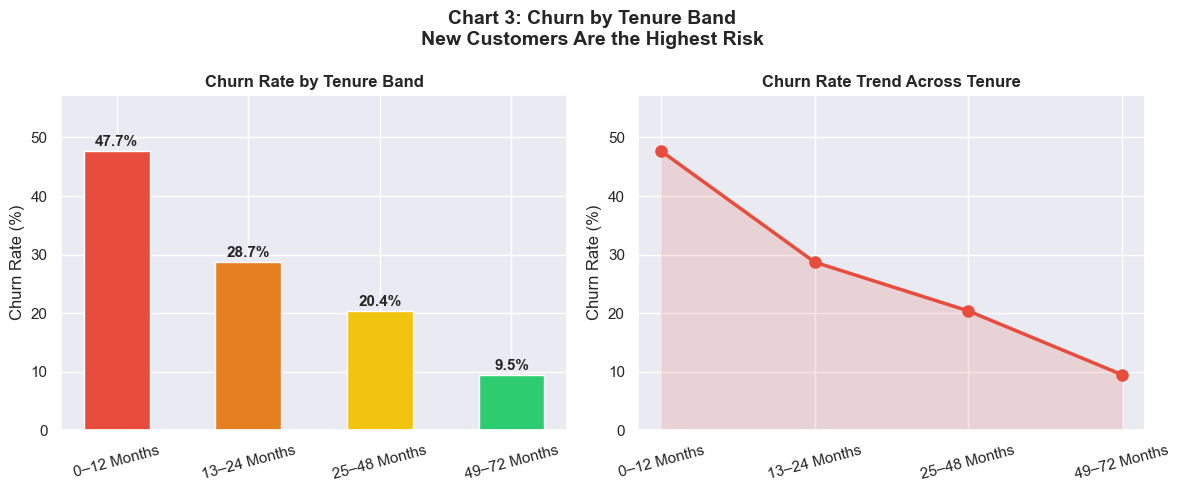

✅ Chart 3 saved

💡 Story: Customers in first 12 months churn at 47.7%
   Risk drops sharply after 24 months — early engagement is critical
   Recommendation: Deploy onboarding programs for first 6 months


In [9]:
# Create tenure bands first
bins = [0, 12, 24, 48, 72]
labels_tenure = ['0–12 Months', '13–24 Months', '25–48 Months', '49–72 Months']
df['TenureBand'] = pd.cut(df['tenure'], bins=bins, labels=labels_tenure)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 3: Churn by Tenure Band\nNew Customers Are the Highest Risk',
             fontsize=14, fontweight='bold')

tenure_churn = df.groupby('TenureBand', observed=True)['Churn'].value_counts(normalize=True).unstack()
tenure_counts = df.groupby('TenureBand', observed=True)['Churn'].value_counts().unstack()
bands = tenure_churn.index.tolist()
churn_rates_t = tenure_churn['Yes'].values * 100
colors_t = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

# Bar Chart — Churn Rate %
axes[0].bar(bands, churn_rates_t, color=colors_t, width=0.5)
axes[0].set_title('Churn Rate by Tenure Band', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, max(churn_rates_t) * 1.2)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(churn_rates_t):
    axes[0].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Line Chart — Churn trend across tenure
axes[1].plot(bands, churn_rates_t, marker='o', color='#e74c3c',
             linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(bands)), churn_rates_t, alpha=0.15, color='#e74c3c')
axes[1].set_title('Churn Rate Trend Across Tenure', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticks(range(len(bands)))
axes[1].set_xticklabels(bands, rotation=15)
axes[1].set_ylim(0, max(churn_rates_t) * 1.2)

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\chart3_churn_by_tenure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")
print(f"\n💡 Story: Customers in first 12 months churn at {churn_rates_t[0]:.1f}%")
print(f"   Risk drops sharply after 24 months — early engagement is critical")
print(f"   Recommendation: Deploy onboarding programs for first 6 months")

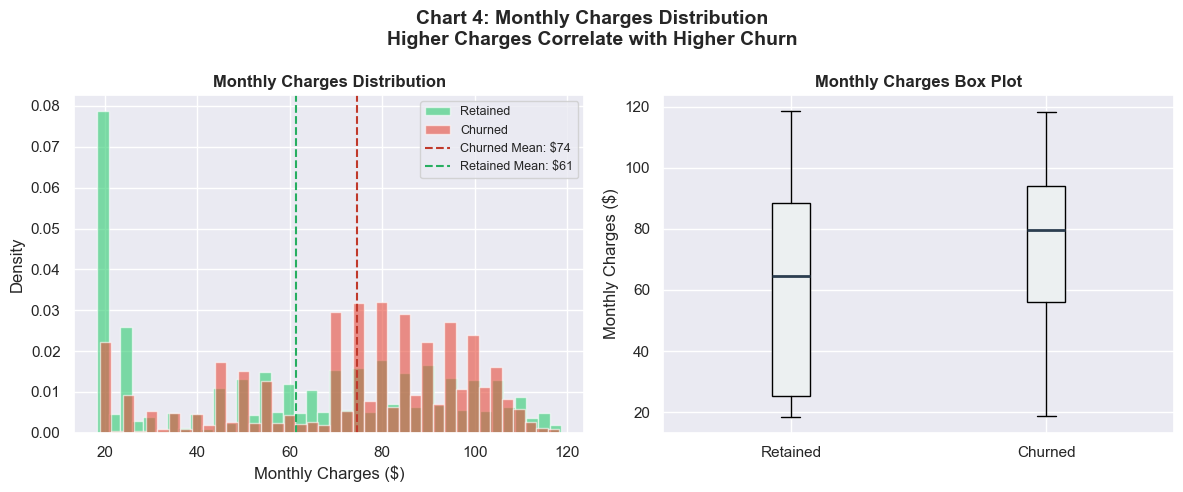

✅ Chart 4 saved

💡 Story: Churned customers pay avg $74.44/mo vs $61.27/mo for retained
   $13.18 higher monthly charge among churners
   Recommendation: Review pricing tiers — high-charge customers need value reinforcement


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 4: Monthly Charges Distribution\nHigher Charges Correlate with Higher Churn',
             fontsize=14, fontweight='bold')

churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained = df[df['Churn'] == 'No']['MonthlyCharges']

# Overlapping Histogram
axes[0].hist(retained, bins=40, alpha=0.6, color='#2ecc71', label='Retained', density=True)
axes[0].hist(churned, bins=40, alpha=0.6, color='#e74c3c', label='Churned', density=True)
axes[0].set_title('Monthly Charges Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(churned.mean(), color='#c0392b', linestyle='--', linewidth=1.5,
                label=f'Churned Mean: ${churned.mean():.0f}')
axes[0].axvline(retained.mean(), color='#27ae60', linestyle='--', linewidth=1.5,
                label=f'Retained Mean: ${retained.mean():.0f}')
axes[0].legend(fontsize=9)

# Box Plot
axes[1].boxplot([retained, churned], labels=['Retained', 'Churned'],
                patch_artist=True,
                boxprops=dict(facecolor='#ecf0f1'),
                medianprops=dict(color='#2c3e50', linewidth=2))
axes[1].set_title('Monthly Charges Box Plot', fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\chart4_monthly_charges.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")
print(f"\n💡 Story: Churned customers pay avg ${churned.mean():.2f}/mo vs ${retained.mean():.2f}/mo for retained")
print(f"   ${churned.mean() - retained.mean():.2f} higher monthly charge among churners")
print(f"   Recommendation: Review pricing tiers — high-charge customers need value reinforcement")

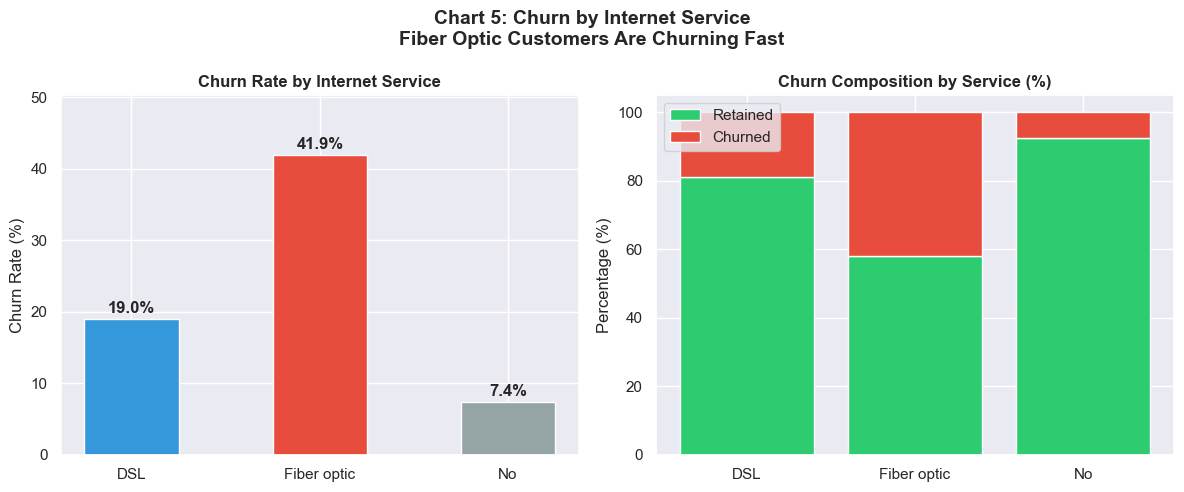

✅ Chart 5 saved

💡 Story: Fiber Optic churn rate = 41.9% — the highest of all service types
   Despite being the premium product, satisfaction appears low
   Recommendation: Investigate Fiber Optic service quality and support issues


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Chart 5: Churn by Internet Service\nFiber Optic Customers Are Churning Fast',
             fontsize=14, fontweight='bold')

internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
internet_counts = df.groupby('InternetService')['Churn'].value_counts().unstack()
services = internet_churn.index.tolist()
churn_rates_i = internet_churn['Yes'].values * 100
colors_i = ['#3498db', '#e74c3c', '#95a5a6']

# Bar Chart — Churn Rate %
axes[0].bar(services, churn_rates_i, color=colors_i, width=0.5)
axes[0].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, max(churn_rates_i) * 1.2)
for i, v in enumerate(churn_rates_i):
    axes[0].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)

# Stacked Bar — Composition
bottom_retained = internet_counts['No'].values
bottom_churned = internet_counts['Yes'].values
total = bottom_retained + bottom_churned
axes[1].bar(services, bottom_retained / total * 100, color='#2ecc71', label='Retained')
axes[1].bar(services, bottom_churned / total * 100,
            bottom=bottom_retained / total * 100, color='#e74c3c', label='Churned')
axes[1].set_title('Churn Composition by Service (%)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\chart5_churn_by_internet.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")
print(f"\n💡 Story: Fiber Optic churn rate = {churn_rates_i[1]:.1f}% — the highest of all service types")
print(f"   Despite being the premium product, satisfaction appears low")
print(f"   Recommendation: Investigate Fiber Optic service quality and support issues")

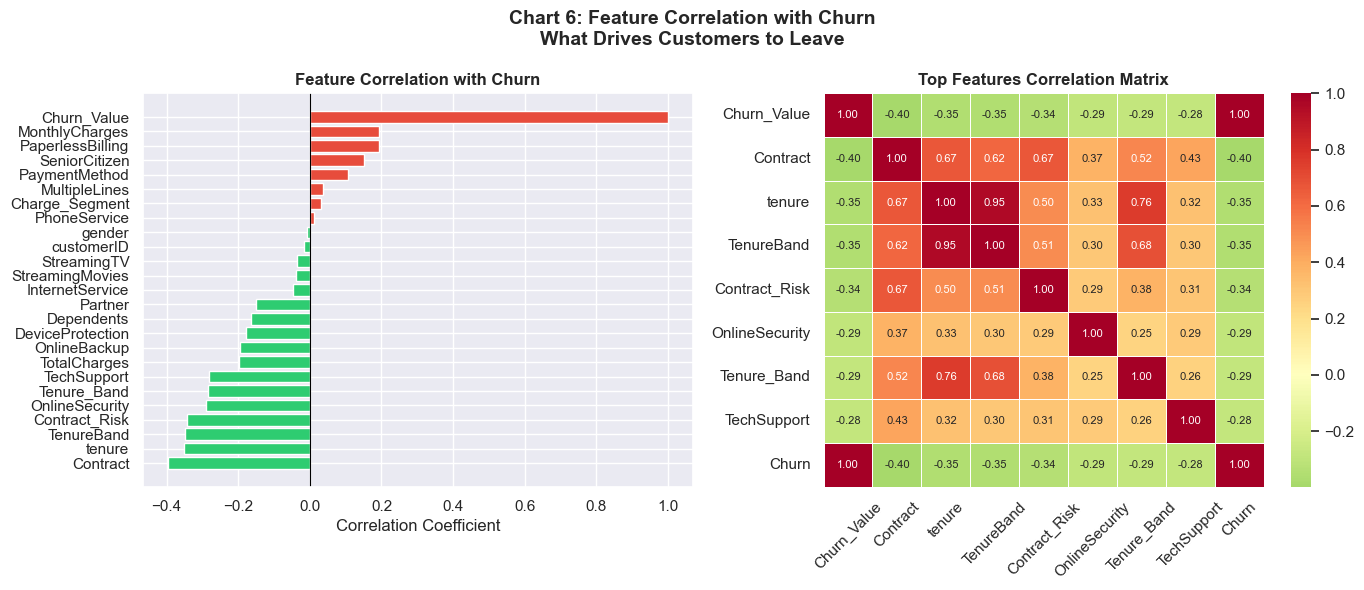

✅ Chart 6 saved

💡 Story: Top churn drivers: Churn_Value, MonthlyCharges, PaperlessBilling
   Contract type & tenure are the strongest protective factors
   Recommendation: Use these features as priority inputs for the ML model


In [12]:
from sklearn.preprocessing import LabelEncoder

# Encode categoricals for correlation
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Drop tenure band (already encoded from object)
if 'TenureBand' in df_encoded.columns:
    df_encoded['TenureBand'] = le.fit_transform(df_encoded['TenureBand'].astype(str))

corr = df_encoded.corr()['Churn'].drop('Churn').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 6: Feature Correlation with Churn\nWhat Drives Customers to Leave',
             fontsize=14, fontweight='bold')

# Horizontal Bar — Correlation with Churn
colors_corr = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr.values]
axes[0].barh(corr.index, corr.values, color=colors_corr)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Churn', fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')

# Full Heatmap (top features)
import seaborn as sns
top_features = corr.abs().nlargest(8).index.tolist() + ['Churn']
corr_matrix = df_encoded[top_features].corr()
sns.heatmap(corr_matrix, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Top Features Correlation Matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\chart6_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")
top_pos = corr.nlargest(3).index.tolist()
print(f"\n💡 Story: Top churn drivers: {', '.join(top_pos)}")
print(f"   Contract type & tenure are the strongest protective factors")
print(f"   Recommendation: Use these features as priority inputs for the ML model")

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ── 1. Work on a clean copy ──────────────────────────────────────────────────
df_model = df.copy()

# ── 2. Drop columns that leak or add no signal ───────────────────────────────
drop_cols = ['customerID', 'TenureBand', 'Churn_Value',
             'Charge_Segment', 'Contract_Risk', 'Tenure_Band']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns],
              inplace=True)

# ── 3. Encode target ─────────────────────────────────────────────────────────
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# ── 4. Binary Yes/No columns → 1/0 ───────────────────────────────────────────
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling']
for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({'Yes': 1, 'No': 0,
                                           'No internet service': 0,
                                           'No phone service': 0})

# ── 5. Gender ─────────────────────────────────────────────────────────────────
df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# ── 6. One-hot encode multi-category columns ──────────────────────────────────
ohe_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

# ── 7. Confirm no nulls ───────────────────────────────────────────────────────
print("✅ Feature Encoding Complete")
print(f"   Shape: {df_model.shape}")
print(f"   Null values: {df_model.isnull().sum().sum()}")
print(f"   Features: {df_model.columns.tolist()}")

✅ Feature Encoding Complete
   Shape: (7043, 24)
   Null values: 0
   Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [16]:
from sklearn.model_selection import train_test_split

# ── Fix: convert any remaining object columns ─────────────────────────────────
object_cols = df_model.select_dtypes(include='object').columns.tolist()
if object_cols:
    print(f"⚠️  Object columns found, fixing: {object_cols}")
    for col in object_cols:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# ── Fix: convert bool columns (from get_dummies) to int ──────────────────────
bool_cols = df_model.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df_model[bool_cols] = df_model[bool_cols].astype(int)

# ── Fix: fill any NaNs introduced by coerce ───────────────────────────────────
df_model.fillna(0, inplace=True)

# ── Verify all dtypes are numeric ─────────────────────────────────────────────
print("✅ Dtype check:")
print(df_model.dtypes.value_counts())
print(f"   Remaining object cols: {df_model.select_dtypes(include='object').columns.tolist()}")

# ── Split ─────────────────────────────────────────────────────────────────────
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n✅ Train/Test Split Complete")
print(f"   Training set : {X_train.shape[0]:,} rows")
print(f"   Test set     : {X_test.shape[0]:,} rows")
print(f"   Churn rate (train): {y_train.mean()*100:.2f}%")
print(f"   Churn rate (test) : {y_test.mean()*100:.2f}%")

⚠️  Object columns found, fixing: ['SeniorCitizen']
✅ Dtype check:
int64      21
float64     3
Name: count, dtype: int64
   Remaining object cols: []

✅ Train/Test Split Complete
   Training set : 5,634 rows
   Test set     : 1,409 rows
   Churn rate (train): 26.54%
   Churn rate (test) : 26.54%


In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

print("✅ XGBoost Model Trained")
print(f"   Features used : {X_train.shape[1]}")
print(f"   Trees built   : {xgb_model.n_estimators}")

✅ XGBoost Model Trained
   Features used : 23
   Trees built   : 200


📊 MODEL EVALUATION RESULTS
  Accuracy  : 75.16%
  ROC-AUC   : 0.8398

              precision    recall  f1-score   support

    Retained       0.90      0.74      0.81      1035
     Churned       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



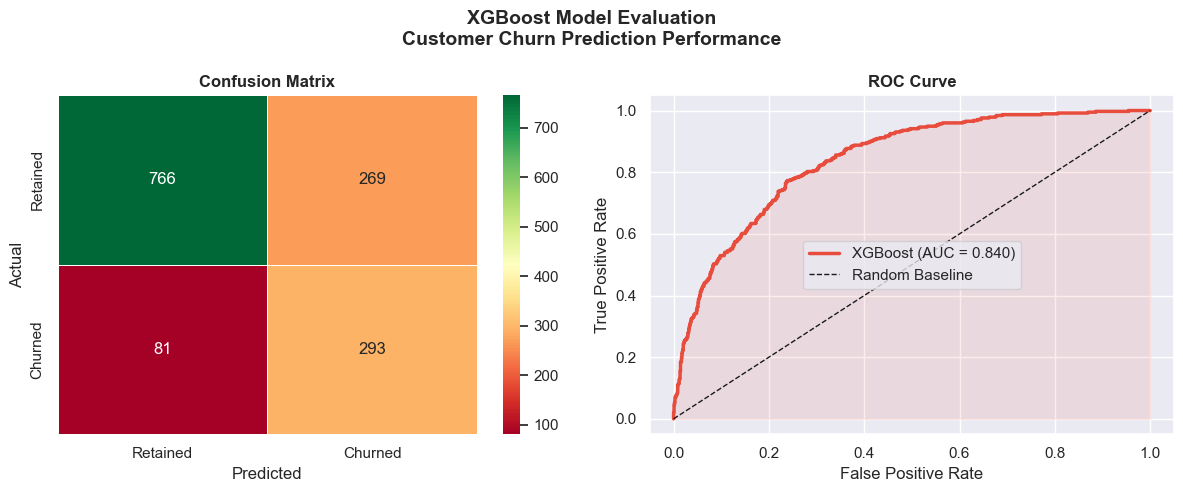

✅ Evaluation chart saved


In [18]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=" * 50)
print("📊 MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Retained', 'Churned']))

# ── Confusion Matrix + ROC Curve side by side ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('XGBoost Model Evaluation\nCustomer Churn Prediction Performance',
             fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
             label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\model_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation chart saved")

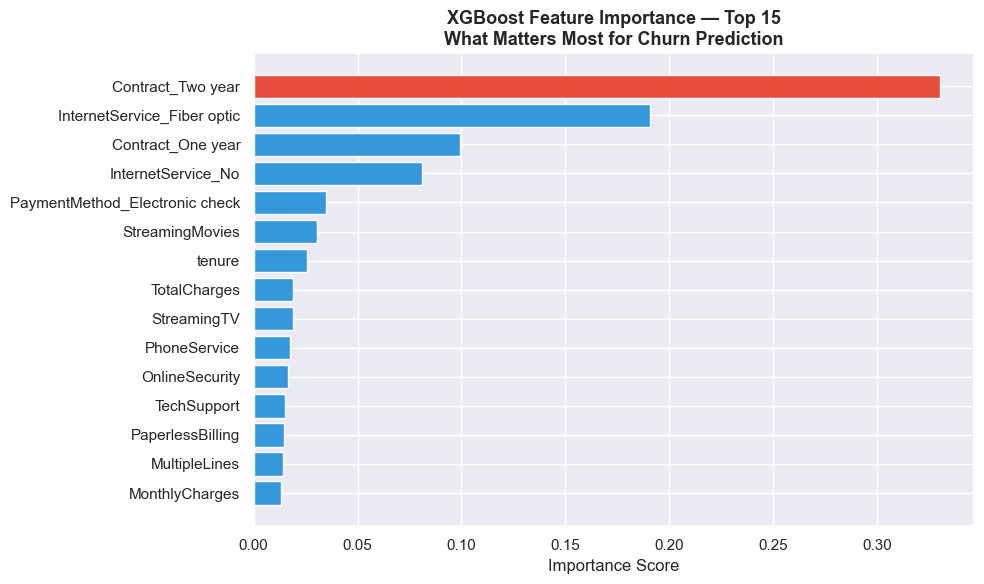

✅ Feature Importance chart saved

💡 Top 3 features: ['Contract_Two year', 'InternetService_Fiber optic', 'Contract_One year']


In [19]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=X_train.columns).sort_values(ascending=True)
top15 = feat_imp.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#e74c3c' if v == top15.max() else '#3498db' for v in top15.values]
ax.barh(top15.index, top15.values, color=colors_fi)
ax.set_title('XGBoost Feature Importance — Top 15\nWhat Matters Most for Churn Prediction',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(r'C:\Users\ramha\Desktop\Customer Churn Analysis\charts\feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature Importance chart saved")
print(f"\n💡 Top 3 features: {feat_imp.nlargest(3).index.tolist()}")

In [20]:
import joblib

base_path = r'C:\Users\ramha\Desktop\Customer Churn Analysis'

# ── Predictions CSV ───────────────────────────────────────────────────────────
results_df = X_test.copy()
results_df['Actual_Churn']      = y_test.values
results_df['Predicted_Churn']   = y_pred
results_df['Churn_Probability'] = y_proba.round(4)
results_df['Risk_Tier'] = pd.cut(
    results_df['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)
results_df.to_csv(f'{base_path}\\churn_predictions.csv', index=False)

# ── Encoded dataset CSV ───────────────────────────────────────────────────────
df_model.to_csv(f'{base_path}\\churn_encoded_dataset.csv', index=False)

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(xgb_model, f'{base_path}\\xgb_churn_model.pkl')

print("✅ All exports complete!")
print(f"\n📁 Files saved to: {base_path}")
print(f"   ├── churn_predictions.csv     ({len(results_df):,} rows)")
print(f"   ├── churn_encoded_dataset.csv ({len(df_model):,} rows)")
print(f"   └── xgb_churn_model.pkl")
print(f"\n🏆 Risk Tier Distribution:")
print(results_df['Risk_Tier'].value_counts().to_string())

✅ All exports complete!

📁 Files saved to: C:\Users\ramha\Desktop\Customer Churn Analysis
   ├── churn_predictions.csv     (1,409 rows)
   ├── churn_encoded_dataset.csv (7,043 rows)
   └── xgb_churn_model.pkl

🏆 Risk Tier Distribution:
Risk_Tier
Low Risk       687
High Risk      462
Medium Risk    260
